<a href="https://colab.research.google.com/github/comet-toolkit/comet_training/blob/main/punpy_no_errcorr_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Training Session - CoMet Toolkit: Uncertainties made easy**

#Exercise 1: Explore some of the basic functionality of the punpy tool.

## Objectives

In this exercise we will:

* Get familiar with the MC and LPU uncertainty propagation methods in [**punpy**](https://punpy.readthedocs.io/en/latest/) tool.
* Propagate uncertainties on manually provided input data through a simple measurement functions using [**punpy**](https://punpy.readthedocs.io/en/latest/).
* Run through some simple examples without taking into account error correlation


## *Step 1* - Set up the environment

First, install the the punpy package:

In [1]:
!pip install punpy>=1.0.6

Please hit `Runtime > Restart Session` to properly load these packages into your Google Colab environment...

Then, import the relevant python packages required in this training:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import punpy

❗Note: If this import fails, it is likely because the pip installation has not properly updated in the Google colab session. Please restart session (in runtime tab above).

## *Step 2* - Define measurement function and input data

In this exercise, our aim is to get familiar with the basic functionality of punpy. Here, punpy will be used as a standalone tool (i.e. without combining it with obsarray functionality). We will use an example of a very basic sensor calibration, where we have some digital numbers for the signal (referred to as L0) and the gains (typically obtained from a lab calibration) to convert these to a physical quantity (referred to as L1). E.g., this could be a radiance measurement collected by an in-situ instrument.  

First, we define our measurement function. For use in punpy, this measurement function needs to be written as a Python function that takes the input quantities (on which we have uncertainties available) as arguments and the measurand (to which we want to propagate the uncertainties) as return. For some further information on measurement functions, input quantities and measurand, see the [CoMet webpage](https://www.comet-toolkit.org/user-guide/theory/).

In [3]:
# your measurement function
def calibrate(L0,gains):
   return L0*gains

Here, the measurement function is a very simple analytical function. However, in practice, this measurement function can contain as much complexity (including calls to other packages/external software, ...) as needed. To some extent, the measurement function is treated as a black box, as long as the measurand and input quantities are structured as expected.

Next, we define some example input data. For your own use case, you need to have this information available from other sources (i.e. the input uncertainties need to be understood prior to using punpy).

In [4]:
# your data
wavs = np.array([350,450,550,650,750])
L0 = np.array([0.43,0.8,0.7,0.65,0.9])
gains = np.array([23,26,28,29,31])

# your uncertainties
L0_ut = np.array([0.03690867,0.05,0.04609772,0.04422952,0.05408327]) # total uncertainty of L0
gains_ut = np.array([0.50990195, 0.72801099, 0.60827625, 0.56568542, 0.31622777]) # total uncertainty of gains


## *Step 3* - Propagate uncertainties using MC

After defining the data, the resulting uncertainty budget can then be calculated with punpy using the Monte Carlo (MC) method.

In [5]:
# initialise a punpy MCpropagation object with 10000 MC samples
prop=punpy.MCPropagation(10000)

# apply the measuremnet function to calculate the measurand from the input quantities
L1=calibrate(L0,gains)

# propagate random uncertainties
# The format for the inputs is propagate_random(measurement function, [list of function inputs], [list of uncertainties in the same order of inputs])
L1_ut=prop.propagate_random(calibrate,[L0,gains],
      [L0_ut,gains_ut])

# print the results
print("L1:    ",L1)
print("L1_ut: ",L1_ut)


L1:     [ 9.89 20.8  19.6  18.85 27.9 ]
L1_ut:  [0.87202526 1.43062261 1.3626994  1.32047274 1.71917639]


To know the error correlation of the total uncertainties, we need to sum the covariance of the random and systematic uncertainties. The error correlations can be converted to error covariance and back using some helper functions.

We can then plot and inspect the results:

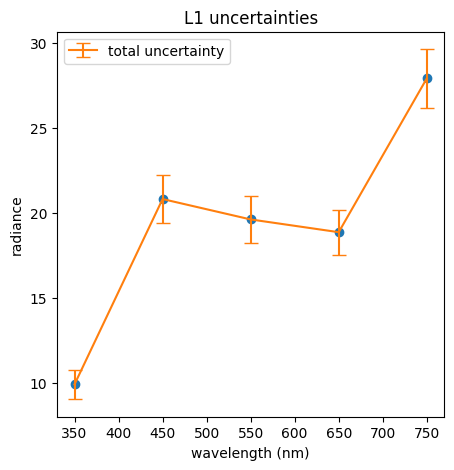

In [6]:
# define plot to show results
def make_plots_L1(L1,L1_ut=None):
  fig,ax1 = plt.subplots(1,figsize=(5,5))

  ax1.plot(wavs,L1,"o")
  if L1_ut is not None:
    ax1.errorbar(wavs,L1,yerr=L1_ut,label="total uncertainty",capsize=5)
  ax1.legend()
  ax1.set_xlabel("wavelength (nm)")
  ax1.set_ylabel("radiance")
  ax1.set_title("L1 uncertainties")
  plt.show()

make_plots_L1(L1,L1_ut)

## *Step 4* - Propagate uncertainties using LPU

Instead of using MC for the uncertainty propagation, we can also use the Law of Propagation of Uncertainty (LPU). This method uses the Jacobian to propagate the uncertainties. The Jacobian can be manually provided, or punpy can calculate it numerically (which is done by default if not Jacobian is provided).

L1:     [ 9.89 20.8  19.6  18.85 27.9 ]
L1_ut:  [0.87675778 1.42449991 1.35915409 1.33431878 1.70056611]


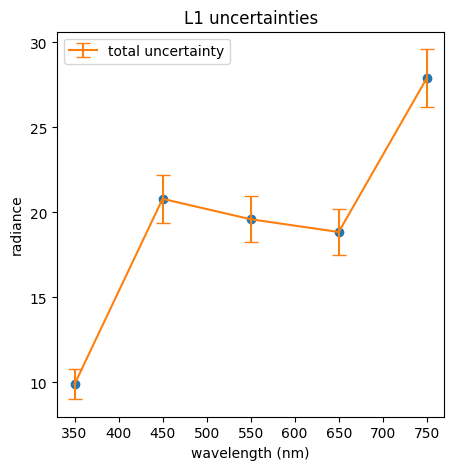

In [7]:
# initialise a punpy LPUPropagation object
prop=punpy.LPUPropagation()

# apply the measuremnet function to calculate the measurand from the input quantities
L1=calibrate(L0,gains)

# propagate random uncertainties
# The format for the inputs is propagate_random(measurement function, [list of function inputs], [list of uncertainties in the same order of inputs])
L1_ut=prop.propagate_random(calibrate,[L0,gains],
      [L0_ut,gains_ut])

# print the results
print("L1:    ",L1)
print("L1_ut: ",L1_ut)

make_plots_L1(L1,L1_ut=L1_ut)

We can also return the numerically calculated Jacobian:

In [8]:
L1_ut, Jx=prop.propagate_random(calibrate,[L0,gains],
      [L0_ut,gains_ut], return_Jacobian=True)
print(Jx.shape)
print(Jx)

(5, 10)
[[23.    0.    0.    0.    0.    0.43  0.    0.    0.    0.  ]
 [ 0.   26.    0.    0.    0.    0.    0.8   0.    0.    0.  ]
 [ 0.    0.   28.    0.    0.    0.    0.    0.7   0.    0.  ]
 [ 0.    0.    0.   29.    0.    0.    0.    0.    0.65  0.  ]
 [ 0.    0.    0.    0.   31.    0.    0.    0.    0.    0.9 ]]


This Jacobain gives the partial derivatives of each of the outputs (5 wavelengths, first dimension) to each of the inputs (2 input quantities times 5 wavelenghts, i.e. 10 values along second dimension). For this simple measurement function, where the two input quantities are simply multiplied, we could have easily performed these partial derivatives manually. We know that $\frac{d(x_1 x_2)}{dx_1} = x_2$ and $\frac{d(x_1 x_2)}{dx_2} = x_1$, and we indeed see the values of the input quantities we defined in Step 2 show up in the Jacobian.

We can also provide a pre-calculated Jacobian (either manually or from a previous punpy run), to punpy to save the computational time of calculating the Jacobian again (which can be an expensive operation for some measurement functions).

L1:     [ 9.89 20.8  19.6  18.85 27.9 ]
L1_ut:  [0.87675778 1.42449991 1.35915409 1.33431878 1.70056611]


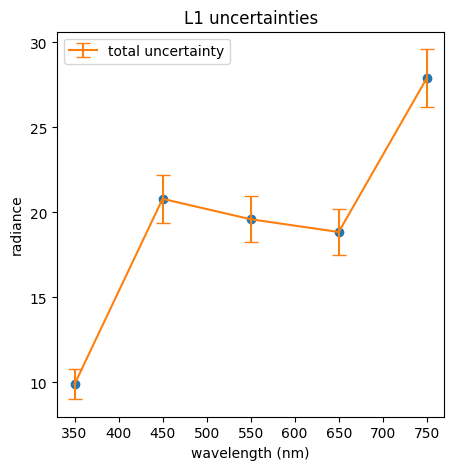

In [9]:
# propagate uncertainties using previously determined Jacobian
L1_ut=prop.propagate_random(calibrate,[L0,gains],
      [L0_ut,gains_ut],Jx=Jx)

# print the results
print("L1:    ",L1)
print("L1_ut: ",L1_ut)

make_plots_L1(L1,L1_ut=L1_ut)

## **Exercise**

Let's add an additional variable to the measurement function, and propagate uncertainties.
In the previous example, we calibrated an in-situ instrument by applying gains to the digital numbers.
Now, let's add some dark measurements, which are subtracted from the digital numbers.

Here is the updated measurement function with the additional input data.

In [10]:
# updated measurement function
def calibrate(L0,gains,dark):
   return (L0-dark)*gains

# additional input quantity
dark = np.array([0.05,0.03,0.04,0.05,0.06])
dark_ut = np.array([0.02,0.02,0.02,0.02,0.02])  # random uncertainty

Try this yourself: propagate the uncertainties through this measurement function using either MC or LPU, based on the examples above.

In [11]:
# initialise a punpy MCpropagation object with 10000 MC samples
prop=punpy.MCPropagation(10000)

# apply the measuremnet function to calculate the measurand from the input quantities
L1=calibrate(L0,gains,dark)

# propagate random uncertainties
# The format for the inputs is propagate_random(measurement function, [list of function inputs], [list of uncertainties in the same order of inputs])
L1_ut=prop.propagate_random(calibrate,[L0,gains,dark],
      [L0_ut,gains_ut,dark_ut])

# print the results
print("L1:    ",L1)
print("L1_ut: ",L1_ut)

L1:     [ 8.74 20.02 18.48 17.4  26.04]
L1_ut:  [0.99199419 1.50760595 1.49031747 1.45973021 1.79670284]


**Question**: What are the total uncertainties (including uncertainties on the dark measurements)?

# **Link to next exercise**
We have now finished going over the basic uncertainty propagation methods without taking into account error correlation.

[Exercise 2](https://colab.research.google.com/github/comet-toolkit/comet_training/blob/main/punpy_with_errcorr.ipynb), showcases how [**punpy**](https://punpy.readthedocs.io/en/latest/) handles propagating error correlation using a very similar example as above.